In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
#Load dataset
df=pd.read_csv('/content/heart_disease_uci.csv')
print("dataset loaded succesfully")

dataset loaded succesfully


In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape

(920, 16)

In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
#identify duplicate records
print("number of duplicate rows:",df.duplicated().sum())

number of duplicate rows: 0


In [ ]:
#null values identification
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
# Define numerical and categorical columns for the new dataset
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

# Create features (X) and target (y) for the new dataset
# Ensure 'num' is binarized for classification, as it contains values > 0
X = df[numerical_cols + categorical_cols].copy() # Explicitly create a copy to avoid SettingWithCopyWarning
y = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Fill numerical missing values with median
for col in numerical_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values after imputation:")
print(X.isnull().sum().sum())


Missing values after imputation:
0


/tmp/ipykernel_3082/325767631.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [ ]:
print("Missing values after preprocessing:")
print(X.isnull().sum())

Missing values after preprocessing:
age         0
trestbps    0
chol        0
thalch      0
oldpeak     0
ca          0
sex         0
dataset     0
cp          0
fbs         0
restecg     0
exang       0
slope       0
thal        0
dtype: int64


In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])

print(df[['sex']].head())

   sex
0    1
1    1
2    1
3    1
4    0


In [ ]:
# One-Hot Encoding

categorical_cols = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df.head())

   id  age  sex    dataset  trestbps   chol  thalch  oldpeak  num  \
0   1   63    1  Cleveland     145.0  233.0   150.0      2.3    0   
1   2   67    1  Cleveland     160.0  286.0   108.0      1.5    2   
2   3   67    1  Cleveland     120.0  229.0   129.0      2.6    1   
3   4   37    1  Cleveland     130.0  250.0   187.0      3.5    0   
4   5   41    0  Cleveland     130.0  204.0   172.0      1.4    0   

   cp_atypical angina  ...  restecg_normal  restecg_st-t abnormality  \
0               False  ...           False                     False   
1               False  ...           False                     False   
2               False  ...           False                     False   
3               False  ...            True                     False   
4                True  ...           False                     False   

   exang_True  slope_flat  slope_upsloping  ca_1.0  ca_2.0  ca_3.0  \
0       False       False            False   False   False   False   
1        Tru

In [ ]:
df.head()

,id,age,sex,dataset,trestbps,chol,thalch,oldpeak,num,cp_atypical angina,...,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_reversable defect
0,1,63,1,Cleveland,145.0,233.0,150.0,2.3,0,False,...,False,False,False,False,False,False,False,False,False,False
1,2,67,1,Cleveland,160.0,286.0,108.0,1.5,2,False,...,False,False,True,True,False,False,False,True,True,False
2,3,67,1,Cleveland,120.0,229.0,129.0,2.6,1,False,...,False,False,True,True,False,False,True,False,False,True
3,4,37,1,Cleveland,130.0,250.0,187.0,3.5,0,False,...,True,False,False,False,False,False,False,False,True,False
4,5,41,0,Cleveland,130.0,204.0,172.0,1.4,0,True,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
# Drop unnecessary columns

df.drop('id', axis=1, inplace=True, errors='ignore')
df.drop('dataset', axis=1, inplace=True, errors='ignore')

In [ ]:
# Create binary target
df['target'] = (df['num'] > 0).astype(int)

# Drop original target column
df.drop('num', axis=1, inplace=True, errors='ignore')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Check the current columns
print(df.columns)

Index(['age', 'sex', 'trestbps', 'chol', 'thalch', 'oldpeak',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'ca_1.0', 'ca_2.0', 'ca_3.0',
       'thal_normal', 'thal_reversable defect', 'target'],
      dtype='object')


In [ ]:
# Define features (X) and target (y)

# Impute remaining numerical columns in df before defining X and y
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Missing values in df after final imputation:")
print(df[['trestbps', 'chol', 'thalch', 'oldpeak']].isnull().sum())

X = df.drop('target', axis=1)
y = df['target']

print("\nFeatures:")
print(X.columns)

print("\nTarget:")
print(y.head())

Missing values in df after final imputation:
trestbps    0
chol        0
thalch      0
oldpeak     0
dtype: int64

Features:
Index(['age', 'sex', 'trestbps', 'chol', 'thalch', 'oldpeak',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'ca_1.0', 'ca_2.0', 'ca_3.0',
       'thal_normal', 'thal_reversable defect'],
      dtype='object')

Target:
0    0
1    1
2    1
3    0
4    0
Name: target, dtype: int64


In [ ]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (736, 20)
Testing data: (184, 20)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression

# Initialize and train a Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for robustness
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("True Positive (TP):", TP)
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)

Confusion Matrix:
[[65 17]
 [12 90]]
True Positive (TP): 90
True Negative (TN): 65
False Positive (FP): 17
False Negative (FN): 12


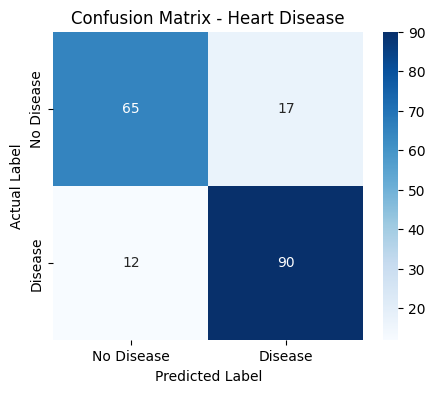

In [ ]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Heart Disease")

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Accuracy : 0.842391304347826
Precision: 0.8411214953271028
Recall   : 0.8823529411764706


In [ ]:
from sklearn.metrics import classification_report

class_report = classification_report(y_test, y_pred)

print(class_report)

              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

print("\nAUC Score :", auc_score)


AUC Score : 0.9071018651362984


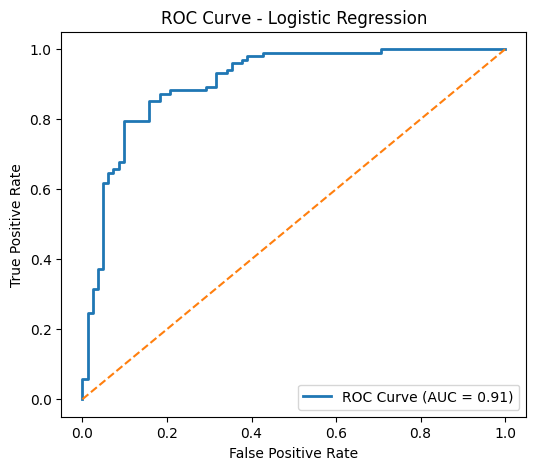

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,linewidth=2,label='ROC Curve (AUC = %0.2f)' % auc_score
)

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()